In [5]:
import numpy as np
import cv2
from PIL import Image
def get_bottom_middle_coords(contours, label):
    bottom_coords = []
    for contour in contours:
        contour = contour.squeeze()
        if contour.ndim != 2:
            continue
        # Find the bottom-most point(s)
        max_y = np.max(contour[:, 1])
        bottom_points = contour[contour[:, 1] == max_y]
        # Calculate the middle x of bottom points
        middle_x = int(np.mean(bottom_points[:, 0]))
        bottom_coords.append({
            "class": label,
            "bottom_middle_coordinate": (middle_x, int(max_y))
        })
    return bottom_coords
def obj_coords(img):
    image_path = img
    Image.MAX_IMAGE_PIXELS = None
    img = Image.open(image_path)
    width, height = img.size
    width = int(width / 2)
    height = int(height /2)
    img = img.resize((width, height), Image.Resampling.LANCZOS)
    image_np = np.array(img)

    # Convert image to grayscale mask to identify regions
    # Define color ranges for red and green in BGR format
    red_lower = np.array([0, 0, 128])
    red_upper = np.array([100, 100, 255])
    green_lower = np.array([0, 128, 0])
    green_upper = np.array([100, 255, 100])

    # Convert the image from RGB to BGR for OpenCV processing
    image_bgr = cv2.cvtColor(image_np, cv2.COLOR_RGB2BGR)

    # Create masks
    red_mask = cv2.inRange(image_bgr, red_lower, red_upper)
    green_mask = cv2.inRange(image_bgr, green_lower, green_upper)

    # Find contours for red and green areas
    red_contours, _ = cv2.findContours(red_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    green_contours, _ = cv2.findContours(green_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Prepare data for output
    object_data = []

    # Get bottom-middle coordinates for both classes
    #red_bottom_coords = get_bottom_middle_coords(red_contours, "red")
    green_bottom_coords = get_bottom_middle_coords(green_contours, "green")

    # Combine and display
    bottom_coords_data = green_bottom_coords
    return bottom_coords_data

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from math import sin, cos, radians, atan2, degrees
import matplotlib.cm as cm
def compute_object_gps(lat_d, lon_d, yaw_deg, pitch_deg, roll_deg, pixel_x, pixel_y, height_agl,
                       f_mm=6.7, sensor_width_mm=10, sensor_height_mm=7.5,
                       image_width_px=8064, image_height_px=6048):
    
    # Umrechnung in metrische Einheiten
    f_m = f_mm / 1000
    sensor_width_m = sensor_width_mm / 1000
    sensor_height_m = sensor_height_mm / 1000

    px_size_x = sensor_width_m / image_width_px
    px_size_y = sensor_height_m / image_height_px

    cx = image_width_px / 2
    cy = image_height_px / 2

    x_sensor = (pixel_x - cx) * px_size_x
    y_sensor = (pixel_y - cy) * px_size_y

    v_cam = np.array([x_sensor, -y_sensor, f_m])
    v_cam = v_cam / np.linalg.norm(v_cam)

    def rotation_matrix(yaw, pitch, roll):
        yaw = radians(yaw)
        pitch = radians(pitch)
        roll = radians(roll)

        R_yaw = np.array([
            [cos(yaw), -sin(yaw), 0],
            [sin(yaw), cos(yaw), 0],
            [0, 0, 1]
        ])
        R_pitch = np.array([
            [cos(pitch), 0, sin(pitch)],
            [0, 1, 0],
            [-sin(pitch), 0, cos(pitch)]
        ])
        R_roll = np.array([
            [1, 0, 0],
            [0, cos(roll), -sin(roll)],
            [0, sin(roll), cos(roll)]
        ])
        return R_yaw @ R_pitch @ R_roll

    R = rotation_matrix(yaw_deg, pitch_deg, roll_deg)
    v_world = R @ v_cam

    P_drone = np.array([0, 0, height_agl])
    t = -P_drone[2] / v_world[2]
    P_object = P_drone + t * v_world

    delta_north = P_object[1]
    delta_east = P_object[0]
    

    delta_lat = delta_north / 110574
    delta_lon = delta_east / (111320 * cos(radians(lat_d)))

    lat_obj = lat_d + delta_lat
    lon_obj = lon_d + delta_lon

    return lat_obj, lon_obj

In [7]:
import matplotlib.pyplot as plt
def plot_objects_on_map(objects,height, lat_d, lon_d, yaw, pitch, roll):
    latitudes = []
    longitudes = []
    labels = []

    for obj in objects:
        label = obj['class']
        x, y = obj['bottom_middle_coordinate']
        lat, lon, calc_yaw = compute_object_gps(lat_d, lon_d, yaw, pitch, roll, x, y, height)
        latitudes.append(lat)
        longitudes.append(lon)
        labels.append(label)

    # Farben je Klasse
    unique_labels = list(set(labels))
    colormap = cm.get_cmap('tab10', len(unique_labels))
    label_to_color = {label: colormap(i) for i, label in enumerate(unique_labels)}

    # Plot
    plt.figure(figsize=(10, 8))
    for lat, lon, label in zip(latitudes, longitudes, labels):
        plt.scatter(lon, lat, color=label_to_color[label], label=label, s=50)
    plt.scatter(lon_d, lat_d, color="red")
    # Legende ohne Wiederholung
    handles, lbls = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(lbls, handles))
    plt.legend(by_label.values(), by_label.keys())

    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title("Detected Object Positions")
    plt.grid(True)
    plt.axis('equal')
    plt.show()

In [8]:
import subprocess
import json
def read_dji_metadata(dng_path):
    # Run exiftool with JSON output
    result = subprocess.run(["exiftool", "-n", "-j", dng_path],
                            stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)
    if result.returncode != 0:
        raise Exception("ExifTool error:\n" + result.stderr)

    metadata = json.loads(result.stdout)[0]
    # Extract relevant fields (fallback to None if missing)
    gps_lat = float(metadata.get("GPSLatitude"))
    gps_lon = float(metadata.get("GPSLongitude"))
    gps_alt = -1*float(metadata.get("AbsoluteAltitude"))+10

    # DJI-specific fields
    #pitch = float(metadata.get("FlightPitchDegree"))
    pitch = -23.9
    roll = float(metadata.get("FlightRollDegree"))
    yaw = float(metadata.get("FlightYawDegree"))
    yaw = (90 - yaw) % 360

    return gps_lat, gps_lon, yaw, pitch, roll, gps_alt

In [11]:
import numpy as np
from math import sin, cos, radians, atan2, degrees
import matplotlib.pyplot as plt
import os
indir = "raw_masks/filled"
dng_path = "/Volumes/Untitled/DCIM/100MEDIA"
dngs= [file for file in os.listdir(dng_path) if file.endswith('.DNG')]
imgs = os.listdir(indir)


In [12]:
from collections import defaultdict
labeled_coords = defaultdict(list)
droneobjs = {}
imageobjs = {}
for filename in imgs:
    if filename.endswith(".png"):
        num = filename.split("_")[1]
        objects_in_image = obj_coords(os.path.join(indir, filename))
        dng = [f for f in dngs if num in f][0]
        lat_d, lon_d, yaw_deg, pitch_deg, roll_deg,height_agl = read_dji_metadata(os.path.join(dng_path, dng))
        objects_coords = []
        for obj in objects_in_image:
            label = obj['class']
            x, y = obj['bottom_middle_coordinate']
            lat, lon = compute_object_gps(lat_d, lon_d, yaw_deg, pitch_deg, roll_deg, x, y, height_agl)
            labeled_coords[label].append((lat, lon))
        imageobjs[num] = labeled_coords
        droneobjs[num] = lat_d, lon_d
        #plot_objects_on_map(objects_in_image, height_agl, lat_d, lon_d, yaw_deg, pitch_deg, roll_deg)
print(imageobjs)



{'0593': defaultdict(<class 'list'>, {'green': [(44.50213567463265, 1.0761125852937707), (44.50210892751294, 1.0761225745994905), (44.50212078679155, 1.0761183028431698), (44.502119577353966, 1.0761338187059069), (44.50211029490747, 1.076136850227098), (44.50214282402056, 1.0761276516986804), (44.502131365603674, 1.0761307541152076), (44.50213503243872, 1.0761368597068202), (44.502120782181834, 1.0761395368676494), (44.50211474376039, 1.0761447107739524), (44.50207962273208, 1.0761186419296882), (44.50209837094509, 1.0761107905395568), (44.502125609354636, 1.0760933388862293), (44.50209758881022, 1.0761343232432796), (44.50208605008896, 1.076139206005351), (44.50208135792198, 1.0761480959722902), (44.50209678396302, 1.076143755335182), (44.502074951636466, 1.0761490478839304), (44.50211502267016, 1.0761399260624815), (44.5020892380669, 1.076145044590709), (44.50212764623306, 1.0761431217782287), (44.50208867220281, 1.076151772076562), (44.502079518151206, 1.076153239400645), (44.501636

In [13]:
with open('webapp/js/points.json', 'w') as f:
    json.dump(imageobjs, f, indent=2)

/var/folders/8q/bws08zmn4l5g0z8rnn85mh8w0000gn/T/ipykernel_78035/3988913312.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap('tab10', len(unique_labels))


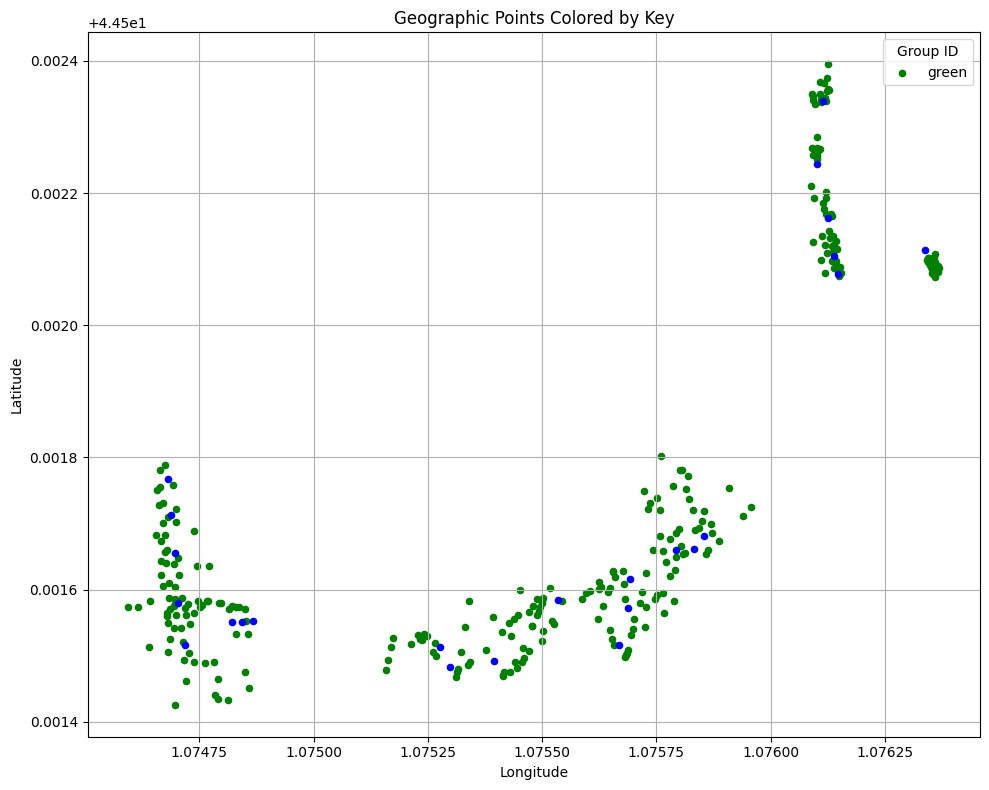

In [14]:
# Create a plot
unique_labels = list(labeled_coords.keys())
colors = cm.get_cmap('tab10', len(unique_labels))
label_color_map = {}
label_color_map["red"] = (1, 0, 0, 1.0)
label_color_map["green"] = (0, 0.5, 0, 1.0)
plt.figure(figsize=(10, 8))
# Plot each group with a unique color and label
for label, coords in labeled_coords.items():
    lats, lons = zip(*coords)
    plt.scatter(lons, lats, color=label_color_map[label], label=label, s=20)
for key, coordinates in droneobjs.items():
    lats,lons = coordinates
    plt.scatter(lons, lats, color="blue", s=20)
# Add labels and legend
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Geographic Points Colored by Key')
plt.legend(title="Group ID")
plt.grid(True)
plt.tight_layout()
plt.show()

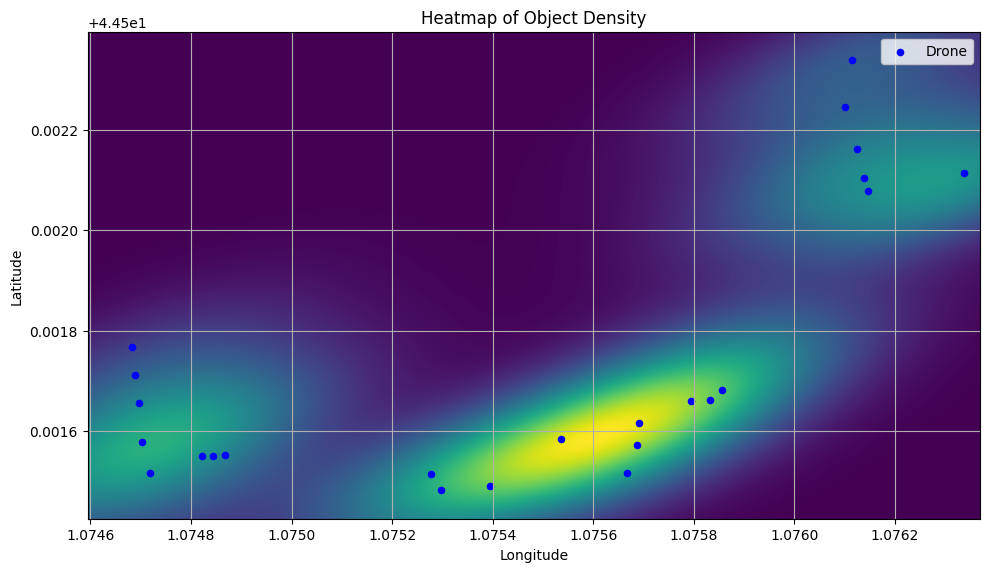

In [15]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

# Flatten all coordinates from all labels into a single list
all_coords = []
for coords in labeled_coords.values():
    all_coords.extend(coords)

# Convert to NumPy arrays
lats, lons = zip(*all_coords)
lats = np.array(lats)
lons = np.array(lons)

# Create a KDE (kernel density estimate) for lat/lon points
xy = np.vstack([lons, lats])
kde = gaussian_kde(xy)
xmin, xmax = lons.min(), lons.max()
ymin, ymax = lats.min(), lats.max()

# Create a grid over the area
xgrid, ygrid = np.mgrid[xmin:xmax:500j, ymin:ymax:500j]
positions = np.vstack([xgrid.ravel(), ygrid.ravel()])
z = kde(positions).reshape(xgrid.shape)

# Plot the heatmap
plt.figure(figsize=(10, 8))
plt.imshow(
    np.rot90(z),  # rotate so north is up
    cmap='viridis',   # or 'viridis', 'inferno', etc.
    extent=[xmin, xmax, ymin, ymax]
)

# Optionally overlay drone positions
for key, (lat, lon) in droneobjs.items():
    plt.scatter(lon, lat, color="blue", s=20, label="Drone" if key == list(droneobjs.keys())[0] else "")

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Heatmap of Object Density")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
def classify_objects(image_path, distance_threshold=200, show_masks=True):
    import numpy as np
    import cv2
    from PIL import Image
    import matplotlib.pyplot as plt
    from scipy.spatial.distance import cdist

    # Load and resize image
    Image.MAX_IMAGE_PIXELS = None
    img = Image.open(image_path)
    image_np = np.array(img)

    # Convert RGB to BGR for OpenCV
    image_bgr = cv2.cvtColor(image_np, cv2.COLOR_RGB2BGR)

    # Define relaxed BGR color ranges
    red_lower = np.array([0, 0, 128])
    red_upper = np.array([100, 100, 255])
    green_lower = np.array([0, 128, 0])
    green_upper = np.array([100, 255, 100])

    # Create binary masks
    red_mask = cv2.inRange(image_bgr, red_lower, red_upper)
    green_mask = cv2.inRange(image_bgr, green_lower, green_upper)

    # Show binary masks if requested
    if show_masks:
        plt.figure(figsize=(12, 5))

        plt.subplot(1, 2, 1)
        plt.imshow(red_mask, cmap='gray')
        plt.title('Red Mask (Bewuchs)')
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.imshow(green_mask, cmap='gray')
        plt.title('Green Mask (Stamm)')
        plt.axis('off')

        plt.tight_layout()
        plt.show()

    # Find contours
    red_contours, _ = cv2.findContours(red_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    green_contours, _ = cv2.findContours(green_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Get centroids of valid contours
    red_centers = []
    for cnt in red_contours:
        M = cv2.moments(cnt)
        if M["m00"] > 0:
            cx = int(M["m10"] / M["m00"])
            cy = int(M["m01"] / M["m00"])
            red_centers.append((cx, cy))

    green_centers = []
    for cnt in green_contours:
        M = cv2.moments(cnt)
        if M["m00"] > 0:
            cx = int(M["m10"] / M["m00"])
            cy = int(M["m01"] / M["m00"])
            green_centers.append((cx, cy))

    red_used = np.zeros(len(red_centers), dtype=bool)
    green_used = np.zeros(len(green_centers), dtype=bool)

    pflanze = 0

    if len(red_centers) > 0 and len(green_centers) > 0:
        dist_matrix = cdist(green_centers, red_centers)
        for i, row in enumerate(dist_matrix):
            for j, dist in enumerate(row):
                if dist < distance_threshold and not red_used[j] and not green_used[i]:
                    pflanze += 1
                    red_used[j] = True
                    green_used[i] = True
                    break

    stamm = np.sum(~green_used)
    bewuchs = np.sum(~red_used)

    return {
        "pflanze": int(pflanze),
        "stamm": int(stamm),
        "bewuchs": int(bewuchs)
    }

Processing Mask  DJI_0596_mask.png


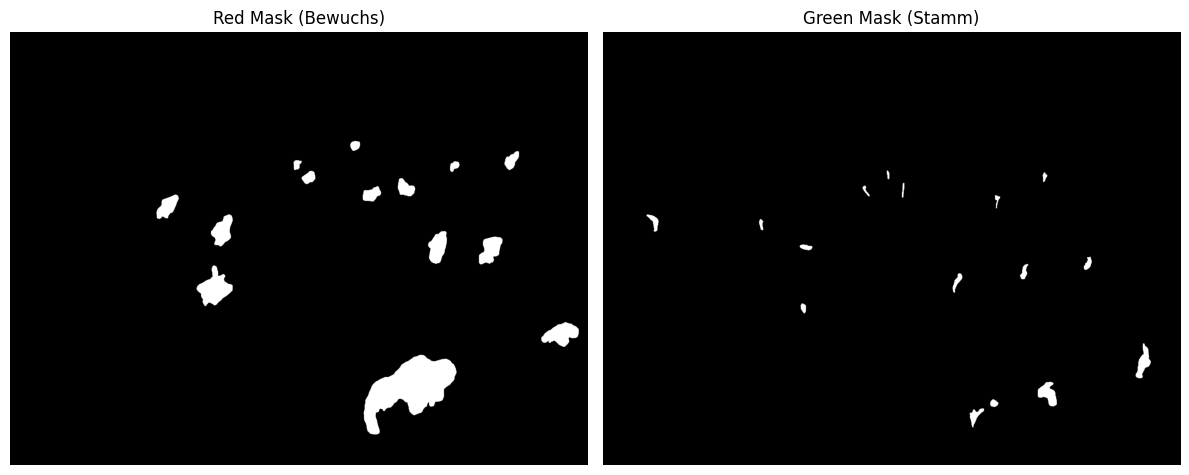

{'pflanze': 1, 'stamm': 15, 'bewuchs': 13}
Processing Mask  DJI_0597_mask.png


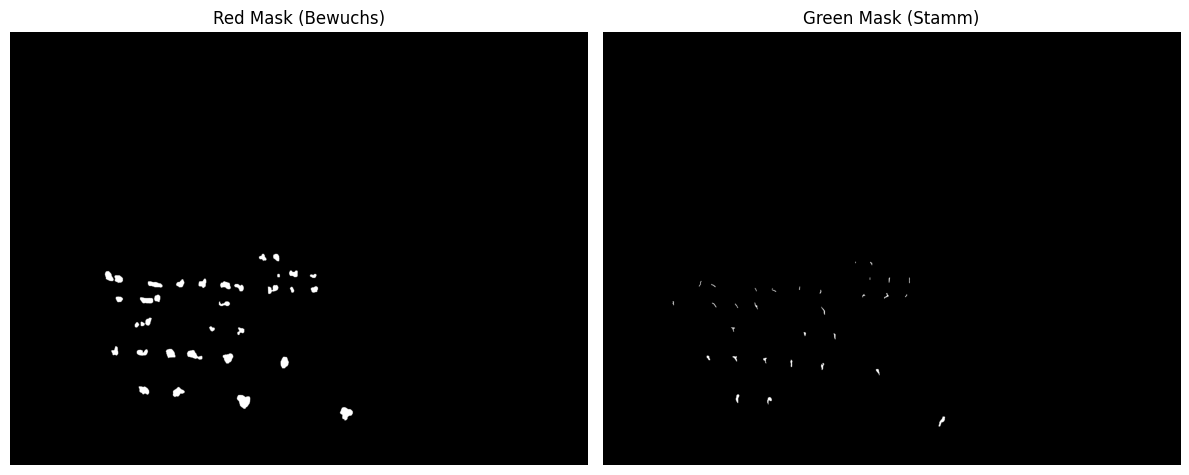

{'pflanze': 30, 'stamm': 1, 'bewuchs': 4}
Processing Mask  DJI_0568_mask.png


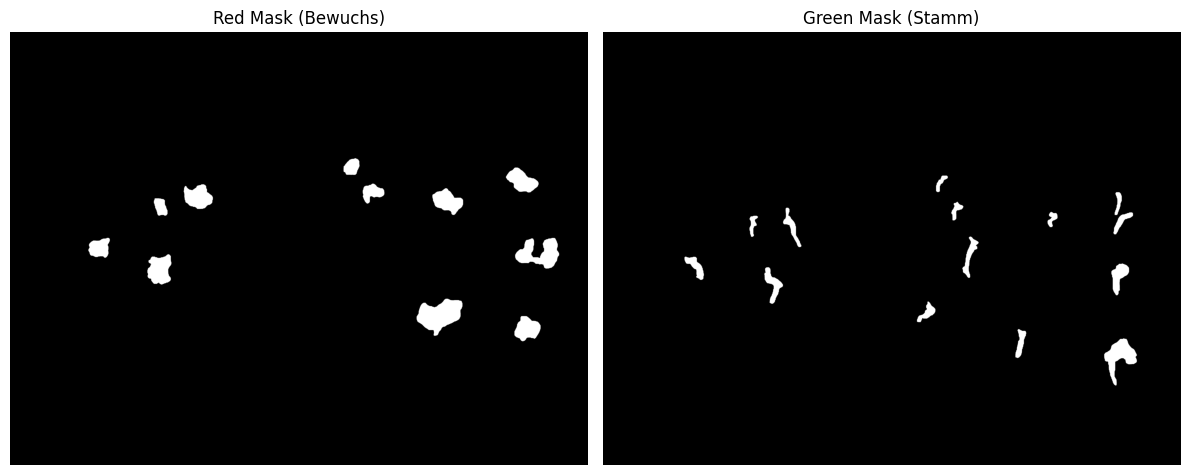

{'pflanze': 0, 'stamm': 14, 'bewuchs': 11}
Processing Mask  DJI_0595_mask.png


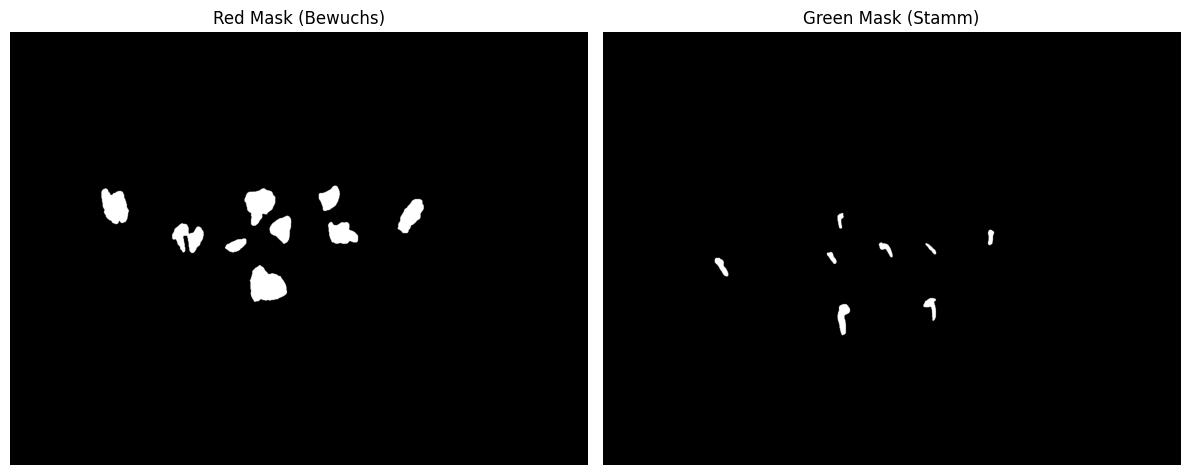

{'pflanze': 0, 'stamm': 8, 'bewuchs': 9}
Processing Mask  DJI_0580_mask.png


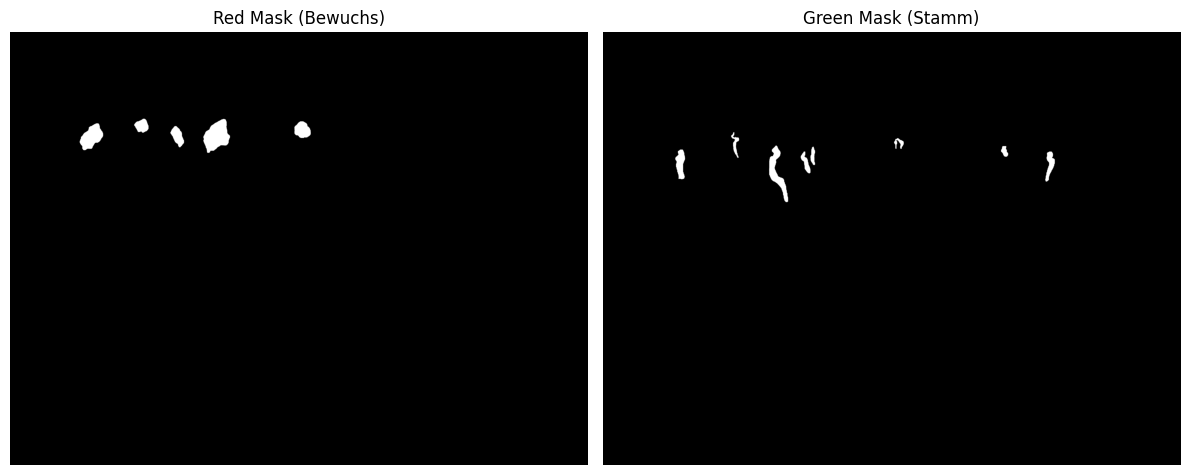

{'pflanze': 0, 'stamm': 8, 'bewuchs': 5}
Processing Mask  DJI_0594_mask.png


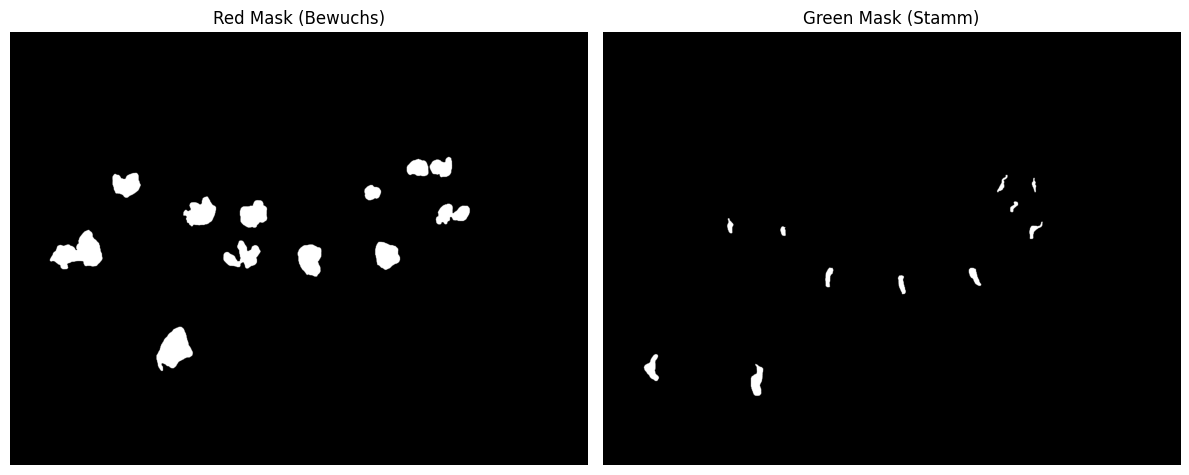

{'pflanze': 0, 'stamm': 11, 'bewuchs': 12}
Processing Mask  DJI_0553_mask.png


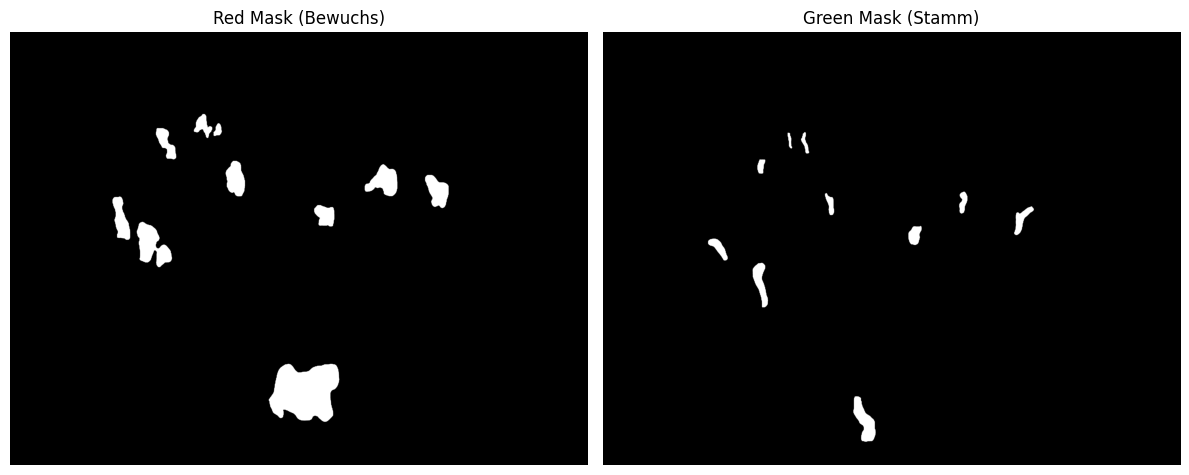

{'pflanze': 0, 'stamm': 10, 'bewuchs': 10}
Processing Mask  DJI_0578_mask.png


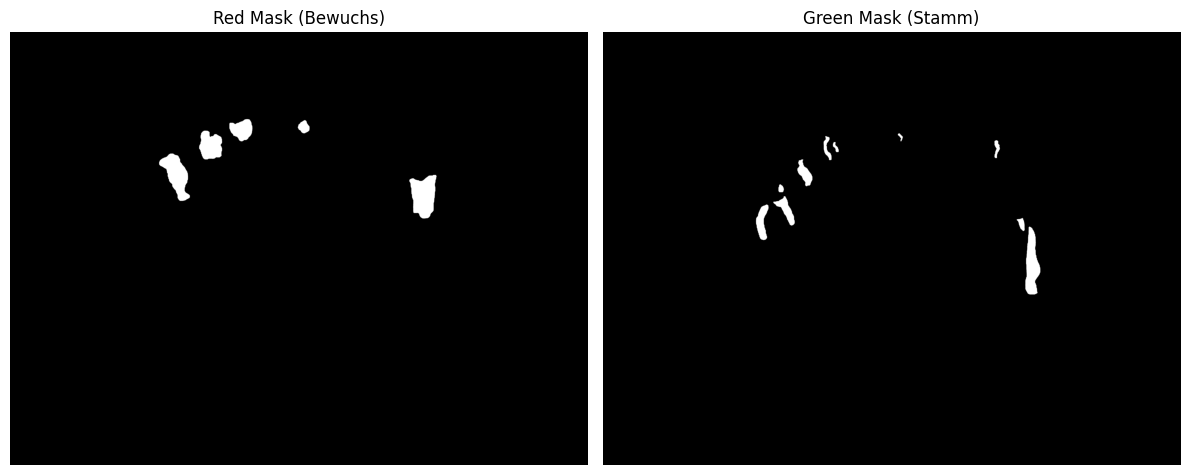

{'pflanze': 1, 'stamm': 9, 'bewuchs': 4}
Processing Mask  DJI_0550_mask.png


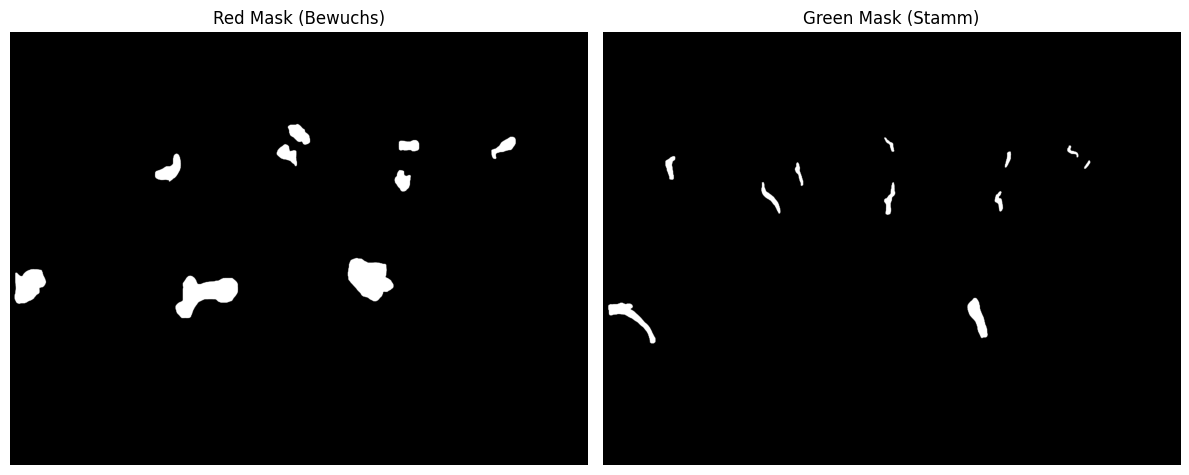

{'pflanze': 0, 'stamm': 11, 'bewuchs': 9}
Processing Mask  DJI_0593_mask.png


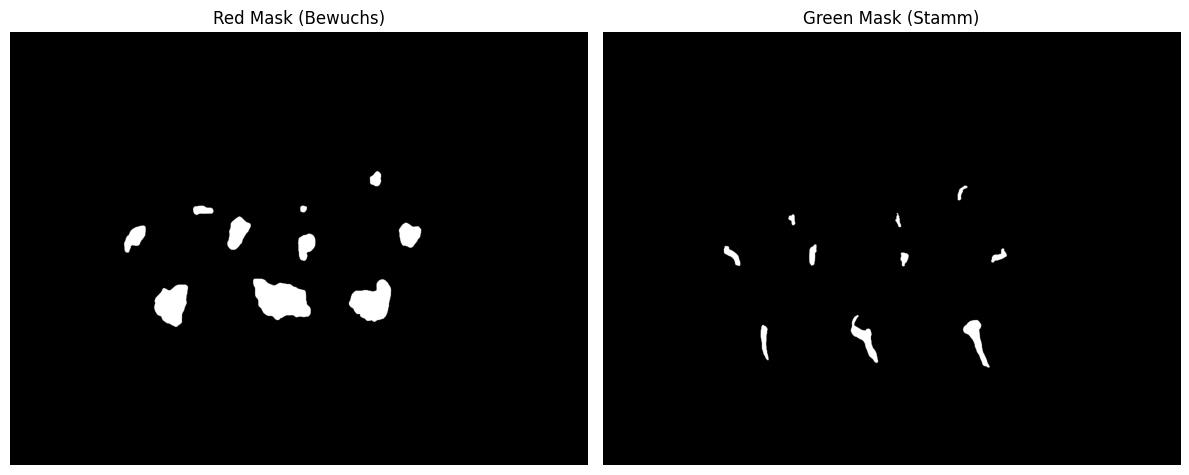

{'pflanze': 1, 'stamm': 9, 'bewuchs': 9}
Processing Mask  DJI_0592_mask.png


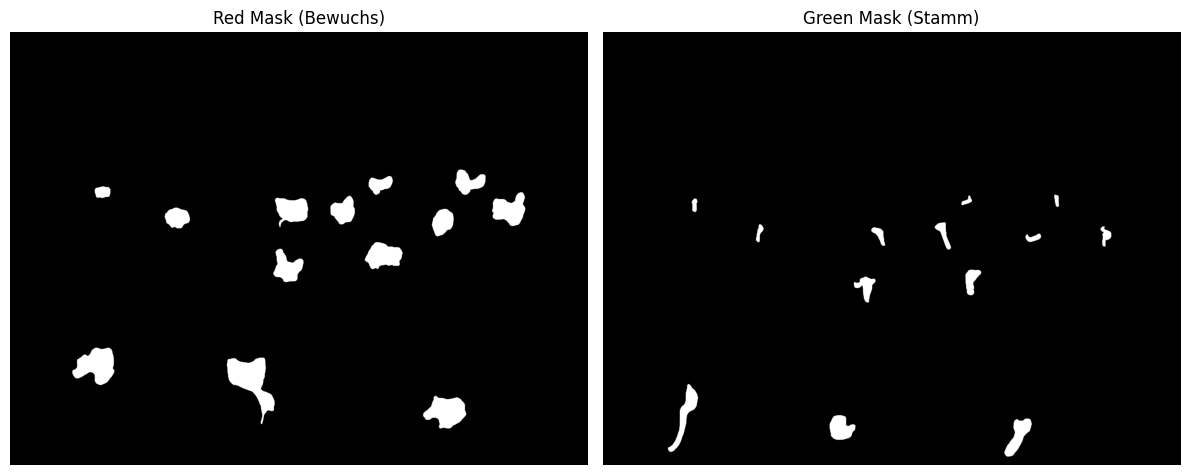

{'pflanze': 0, 'stamm': 13, 'bewuchs': 13}
Processing Mask  DJI_0551_mask.png


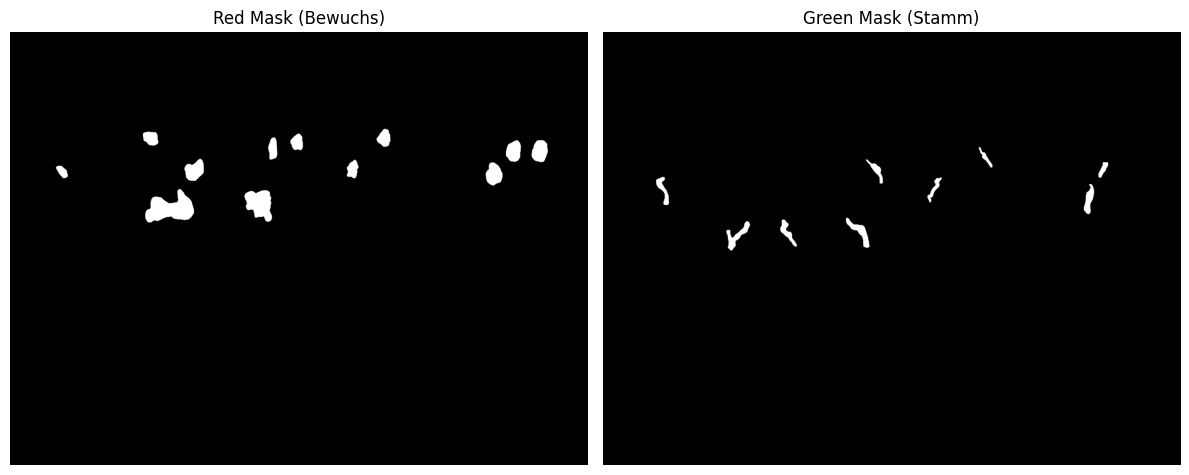

{'pflanze': 0, 'stamm': 9, 'bewuchs': 12}
Processing Mask  DJI_0579_mask.png


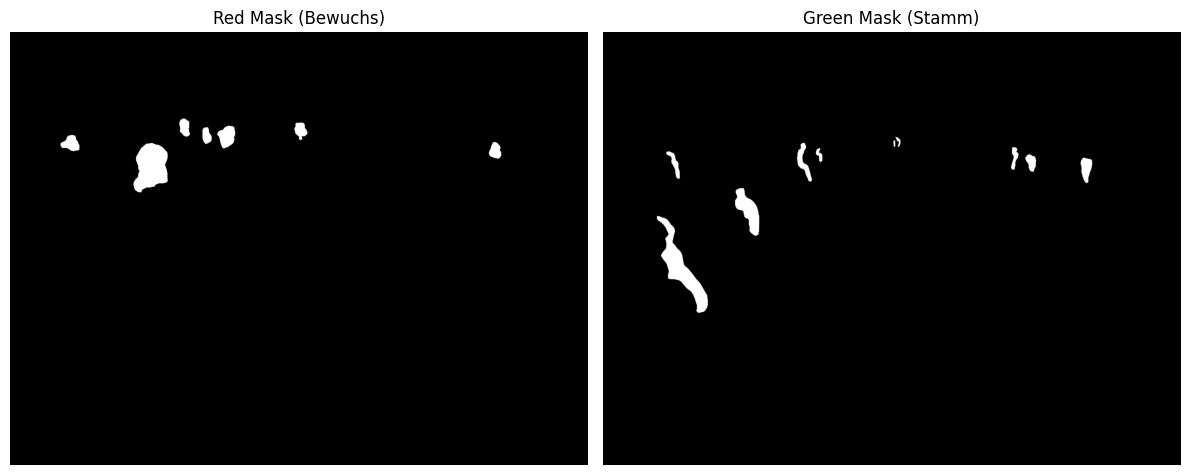

{'pflanze': 0, 'stamm': 10, 'bewuchs': 7}
Processing Mask  DJI_0560_mask.png


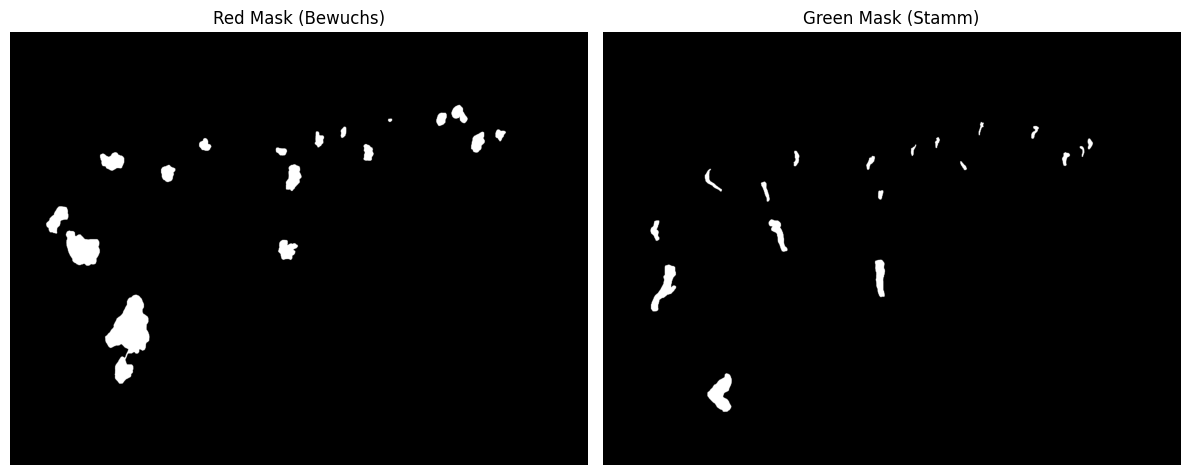

{'pflanze': 3, 'stamm': 15, 'bewuchs': 14}
Processing Mask  DJI_0548_mask.png


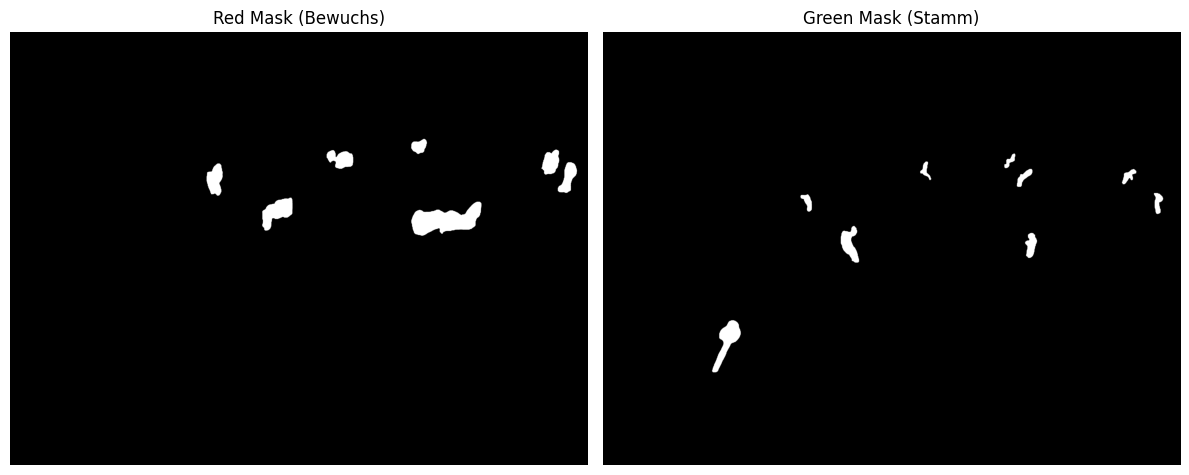

{'pflanze': 0, 'stamm': 9, 'bewuchs': 7}
Processing Mask  DJI_0549_mask.png


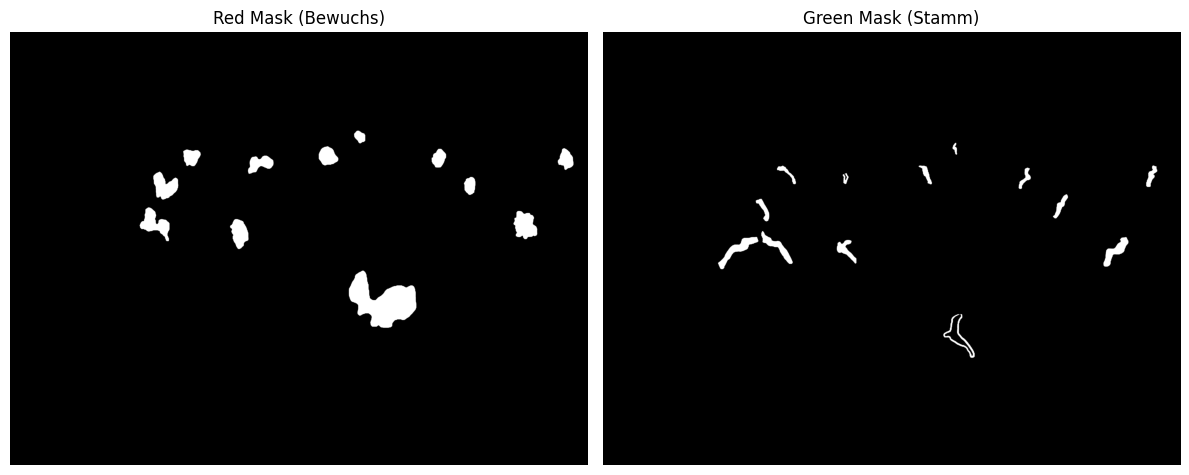

{'pflanze': 0, 'stamm': 13, 'bewuchs': 12}
Processing Mask  DJI_0563_mask.png


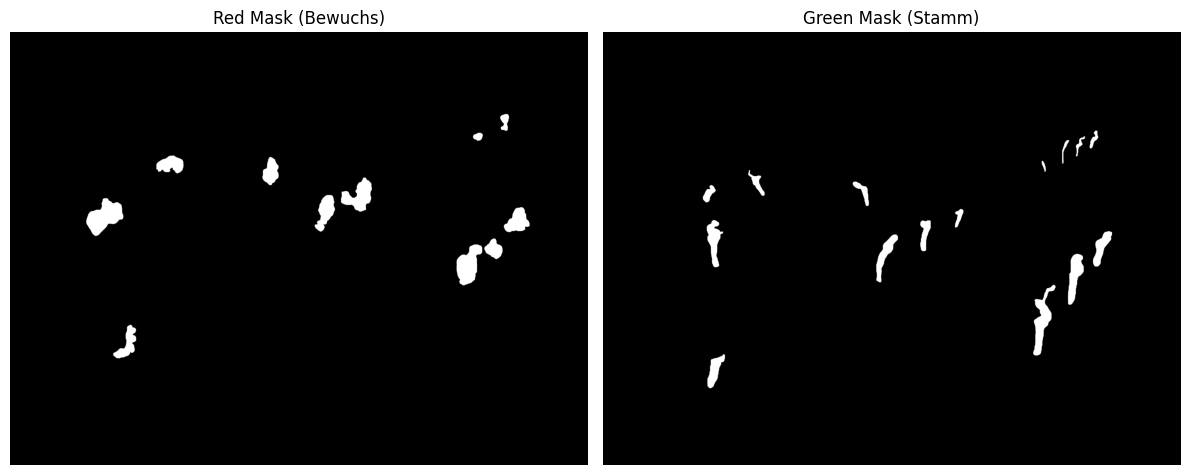

{'pflanze': 0, 'stamm': 15, 'bewuchs': 11}
Processing Mask  DJI_0566_mask.png


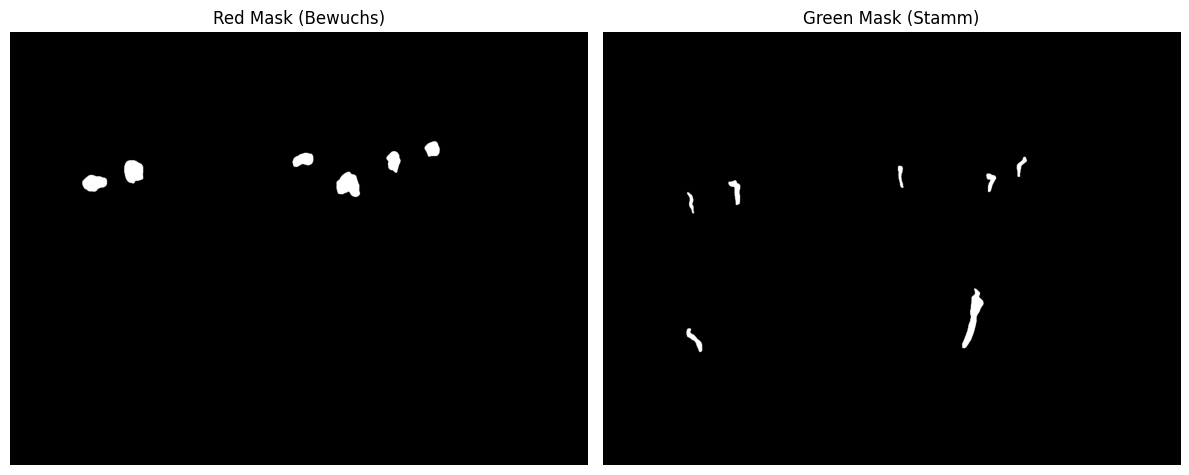

{'pflanze': 0, 'stamm': 7, 'bewuchs': 6}
Processing Mask  DJI_0567_mask.png


In [ ]:
import os
import json
import piexif
from PIL import Image
from pyproj import Transformer
import math

# --- CONFIGURE these to match your camera ---
SENSOR_WIDTH_MM = 10    # e.g. 1/2.3" sensor width in mm
SENSOR_HEIGHT_MM = 7.5   # e.g. 1/2.3" sensor height in mm

# Directory containing your JPGs
IMAGE_DIR = "images/imgs"
OUTPUT_JSON = "webapp/js/footprints.json"

# WGS84 ⇄ local East-North-Up (ENU) transformer
# For each image we'll build a local transformer centered at its GPS lat/lon
def make_enu_transformer(lat0, lon0):
    # geodetic → East, North, Up in metres
    return Transformer.from_crs(
        crs_from="epsg:4326",
        crs_to=f"+proj=tmerc +lat_0={lat0} +lon_0={lon0} +k=1 +units=m +datum=WGS84",
        always_xy=True
    ), Transformer.from_crs(
        crs_from=f"+proj=tmerc +lat_0={lat0} +lon_0={lon0} +k=1 +units=m +datum=WGS84",
        crs_to="epsg:4326",
        always_xy=True
    )

def extract_exif_gps(img_path):
    img = Image.open(img_path)
    exif_dict = piexif.load(img.info["exif"])
    gps = exif_dict["GPS"]
    def conv_rational(r):
        return r[0]/r[1]
    # latitude
    lat_deg = conv_rational(gps[piexif.GPSIFD.GPSLatitude][0])
    lat_min = conv_rational(gps[piexif.GPSIFD.GPSLatitude][1])
    lat_sec = conv_rational(gps[piexif.GPSIFD.GPSLatitude][2])
    lat = lat_deg + lat_min/60 + lat_sec/3600
    if gps[piexif.GPSIFD.GPSLatitudeRef] != b'N':
        lat = -lat
    # longitude
    lon_deg = conv_rational(gps[piexif.GPSIFD.GPSLongitude][0])
    lon_min = conv_rational(gps[piexif.GPSIFD.GPSLongitude][1])
    lon_sec = conv_rational(gps[piexif.GPSIFD.GPSLongitude][2])
    lon = lon_deg + lon_min/60 + lon_sec/3600
    if gps[piexif.GPSIFD.GPSLongitudeRef] != b'E':
        lon = -lon
    # altitude
    alt = conv_rational(gps[piexif.GPSIFD.GPSAltitude])+10
    # focal length (in mm)
    fl = 6.7
    # image size
    width, height = img.size
    return lat, lon, alt, fl, width, height

def compute_footprint(lat, lon, alt, fl, img_w, img_h, yaw, pitch):
    # half-angles in radians
    half_w = (SENSOR_WIDTH_MM / 2) / fl
    half_h = (SENSOR_HEIGHT_MM / 2) / fl
    
    # Calculate ground distances based on the pitch and yaw
    gx = alt * math.tan(half_w)
    gy = alt * math.tan(half_h)

    # Adjust for pitch (vertical angle)
    gx *= math.cos(math.radians(pitch))
    gy *= math.cos(math.radians(pitch))

    # Create the ENU transformer
    to_enu, to_geo = make_enu_transformer(lat, lon)
    east0, north0 = to_enu.transform(lon, lat)

    # Create rotated corner positions based on yaw
    corners_enu = [
        ( east0 - gx, north0 - gy ),
        ( east0 + gx, north0 - gy ),
        ( east0 + gx, north0 + gy ),
        ( east0 - gx, north0 + gy ),
    ]

    # Rotate the corners based on yaw angle (counter-clockwise)
    rotated_corners = []
    for corner in corners_enu:
        x, y = corner
        # Apply the yaw rotation matrix
        rotated_x = x * math.cos(math.radians(yaw)) - y * math.sin(math.radians(yaw))
        rotated_y = x * math.sin(math.radians(yaw)) + y * math.cos(math.radians(yaw))
        rotated_corners.append((rotated_x, rotated_y))

    # Convert back to lon/lat
    poly = [list(to_geo.transform(x, y)) for x, y in rotated_corners]
    return poly

def main():
    results = []
    for fn in os.listdir(IMAGE_DIR):
        if fn.lower().endswith(".jpg"):
            path = os.path.join(IMAGE_DIR, fn)
            lat, lon, alt, fl, w, h = extract_exif_gps(path)
            
            yaw = 90
            pitch = 23.9

            poly = compute_footprint(lat, lon, alt, fl, w, h, yaw, pitch)
            num = fn.split("_")[1].split(".")[0]
            masks = os.listdir("raw_masks/filled")
            for mask in masks:
                if num in mask:
                    print("Processing Mask ", mask)
                    class_counts = classify_objects(os.path.join("raw_masks/filled", mask))
            print(class_counts)
            results.append({
                "filename": fn,
                "footprint": poly,
                "classes": class_counts
            })

    with open(OUTPUT_JSON, "w") as f:
        json.dump(results, f, indent=2)
    print(f"Wrote {len(results)} footprints to {OUTPUT_JSON}")

if __name__ == "__main__":
    main()